# Soccer Pass Clustering

### Goals
- Build a pass clustering model using the spatial characteristics of soccer passes (i.e. `[x1, y1, x2, y2, ...]`) using all passing data from the season.
- Plot the individual pass clusters using `mplsoccer`.
- Calculate the frequency of each pass cluster for Canada during the 2022 World Cup.


In [1]:
# Install Some Dependancies for the Lab
!pip install statsbombpy --quiet
!pip install mplsoccer --quiet

In [2]:
# If you're on a Mac with a retina display, uncomment the below line for clean plotting
%config InlineBackend.figure_format = 'retina'

In [3]:
from statsbombpy import sb

# Some code to suppress warnings about not using an API key – we're using the free dataset
from statsbombpy.api_client import NoAuthWarning
import warnings
warnings.filterwarnings('ignore', category=NoAuthWarning)

## Lab 3 Start

# **Part 1: Data Wrangling & Pass Clustering Model**

In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from mplsoccer import Pitch
import matplotlib.pyplot as plt

Load all matches from the 2022 World Cup, collect ALL passing data from all matches using the x & y coordinates as stated in lab description

clean up by removing any NA's if present

In [5]:
league = {'competition_id': 43, 'season_id': 106}
matches = sb.matches(competition_id=league['competition_id'], season_id=league['season_id'])

all_passes = []
for match_id in matches['match_id']:
    events = sb.events(match_id=match_id)
    passes = events[events['type'] == 'Pass'].copy()
    if not passes.empty:
        passes[['start_x', 'start_y']] = pd.DataFrame(passes['location'].tolist(), index=passes.index)
        passes[['end_x', 'end_y']] = pd.DataFrame(passes['pass_end_location'].tolist(), index=passes.index)
        all_passes.append(passes[['start_x', 'start_y', 'end_x', 'end_y']])

all_passes_df = pd.concat(all_passes, ignore_index=True).dropna()

In [6]:
print(f"Total passes collected: {len(all_passes_df)}")

Total passes collected: 68515


Create a Cluster Model for the 68,515 passes collected over the season

Based on the information provided, I believe a k-means cluster would work best as it is the most common and efficient. As well, the data is in four dimensions (i.e. start x, start y, end x, end y), which is relatively low so there is no need for PCA or t-SNE

A GMM approach could work but based on the sample characteristics where clusters will generally be a similar size and less complex due to nature of passing in a sport, I belive the K-means is sufficient

In [7]:
features = all_passes_df[['start_x', 'start_y', 'end_x', 'end_y']]

Picking a good K: based on the lecture, it described the elbow method to pick the K Value for our clusters. Below I have attempted this

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


#max_k = 40
#inertias = []

#for k in range(1, max_k + 1):
  #  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  #  kmeans.fit(features)
  #  inertias.append(kmeans.inertia_)
#  print(f"Computed inertia for k={k}: {kmeans.inertia_}")  # Optional: Track progress

#Plot the elbow curve
#plt.figure(figsize=(10, 6))
#plt.plot(range(1, max_k + 1), inertias, marker='o')
#plt.xlabel('Number of Clusters (k)')
#plt.ylabel('Inertia (WSS)')
#plt.title('Elbow Method for Optimal k')
#plt.xticks(range(1, max_k + 1, 2))  # Show every other tick for readability
#plt.grid(True)
#plt.show()

Can run if you want but took a few minutes.

The model shows that the mathetmatical elbow is occuring around the 5-10 but based on soccer knowledge, this seems to be too small for the basis of soccer. Instead, I will use a number in the 20-30 range as suggested in class.

**K-Means Model**

In [9]:
n_clusters = 25
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(features)

KMeans(n_clusters=25, n_init=10, random_state=42)

#Part 2: Plot the clusters using mplsoccer

Create a plot of the 25 independent clusters

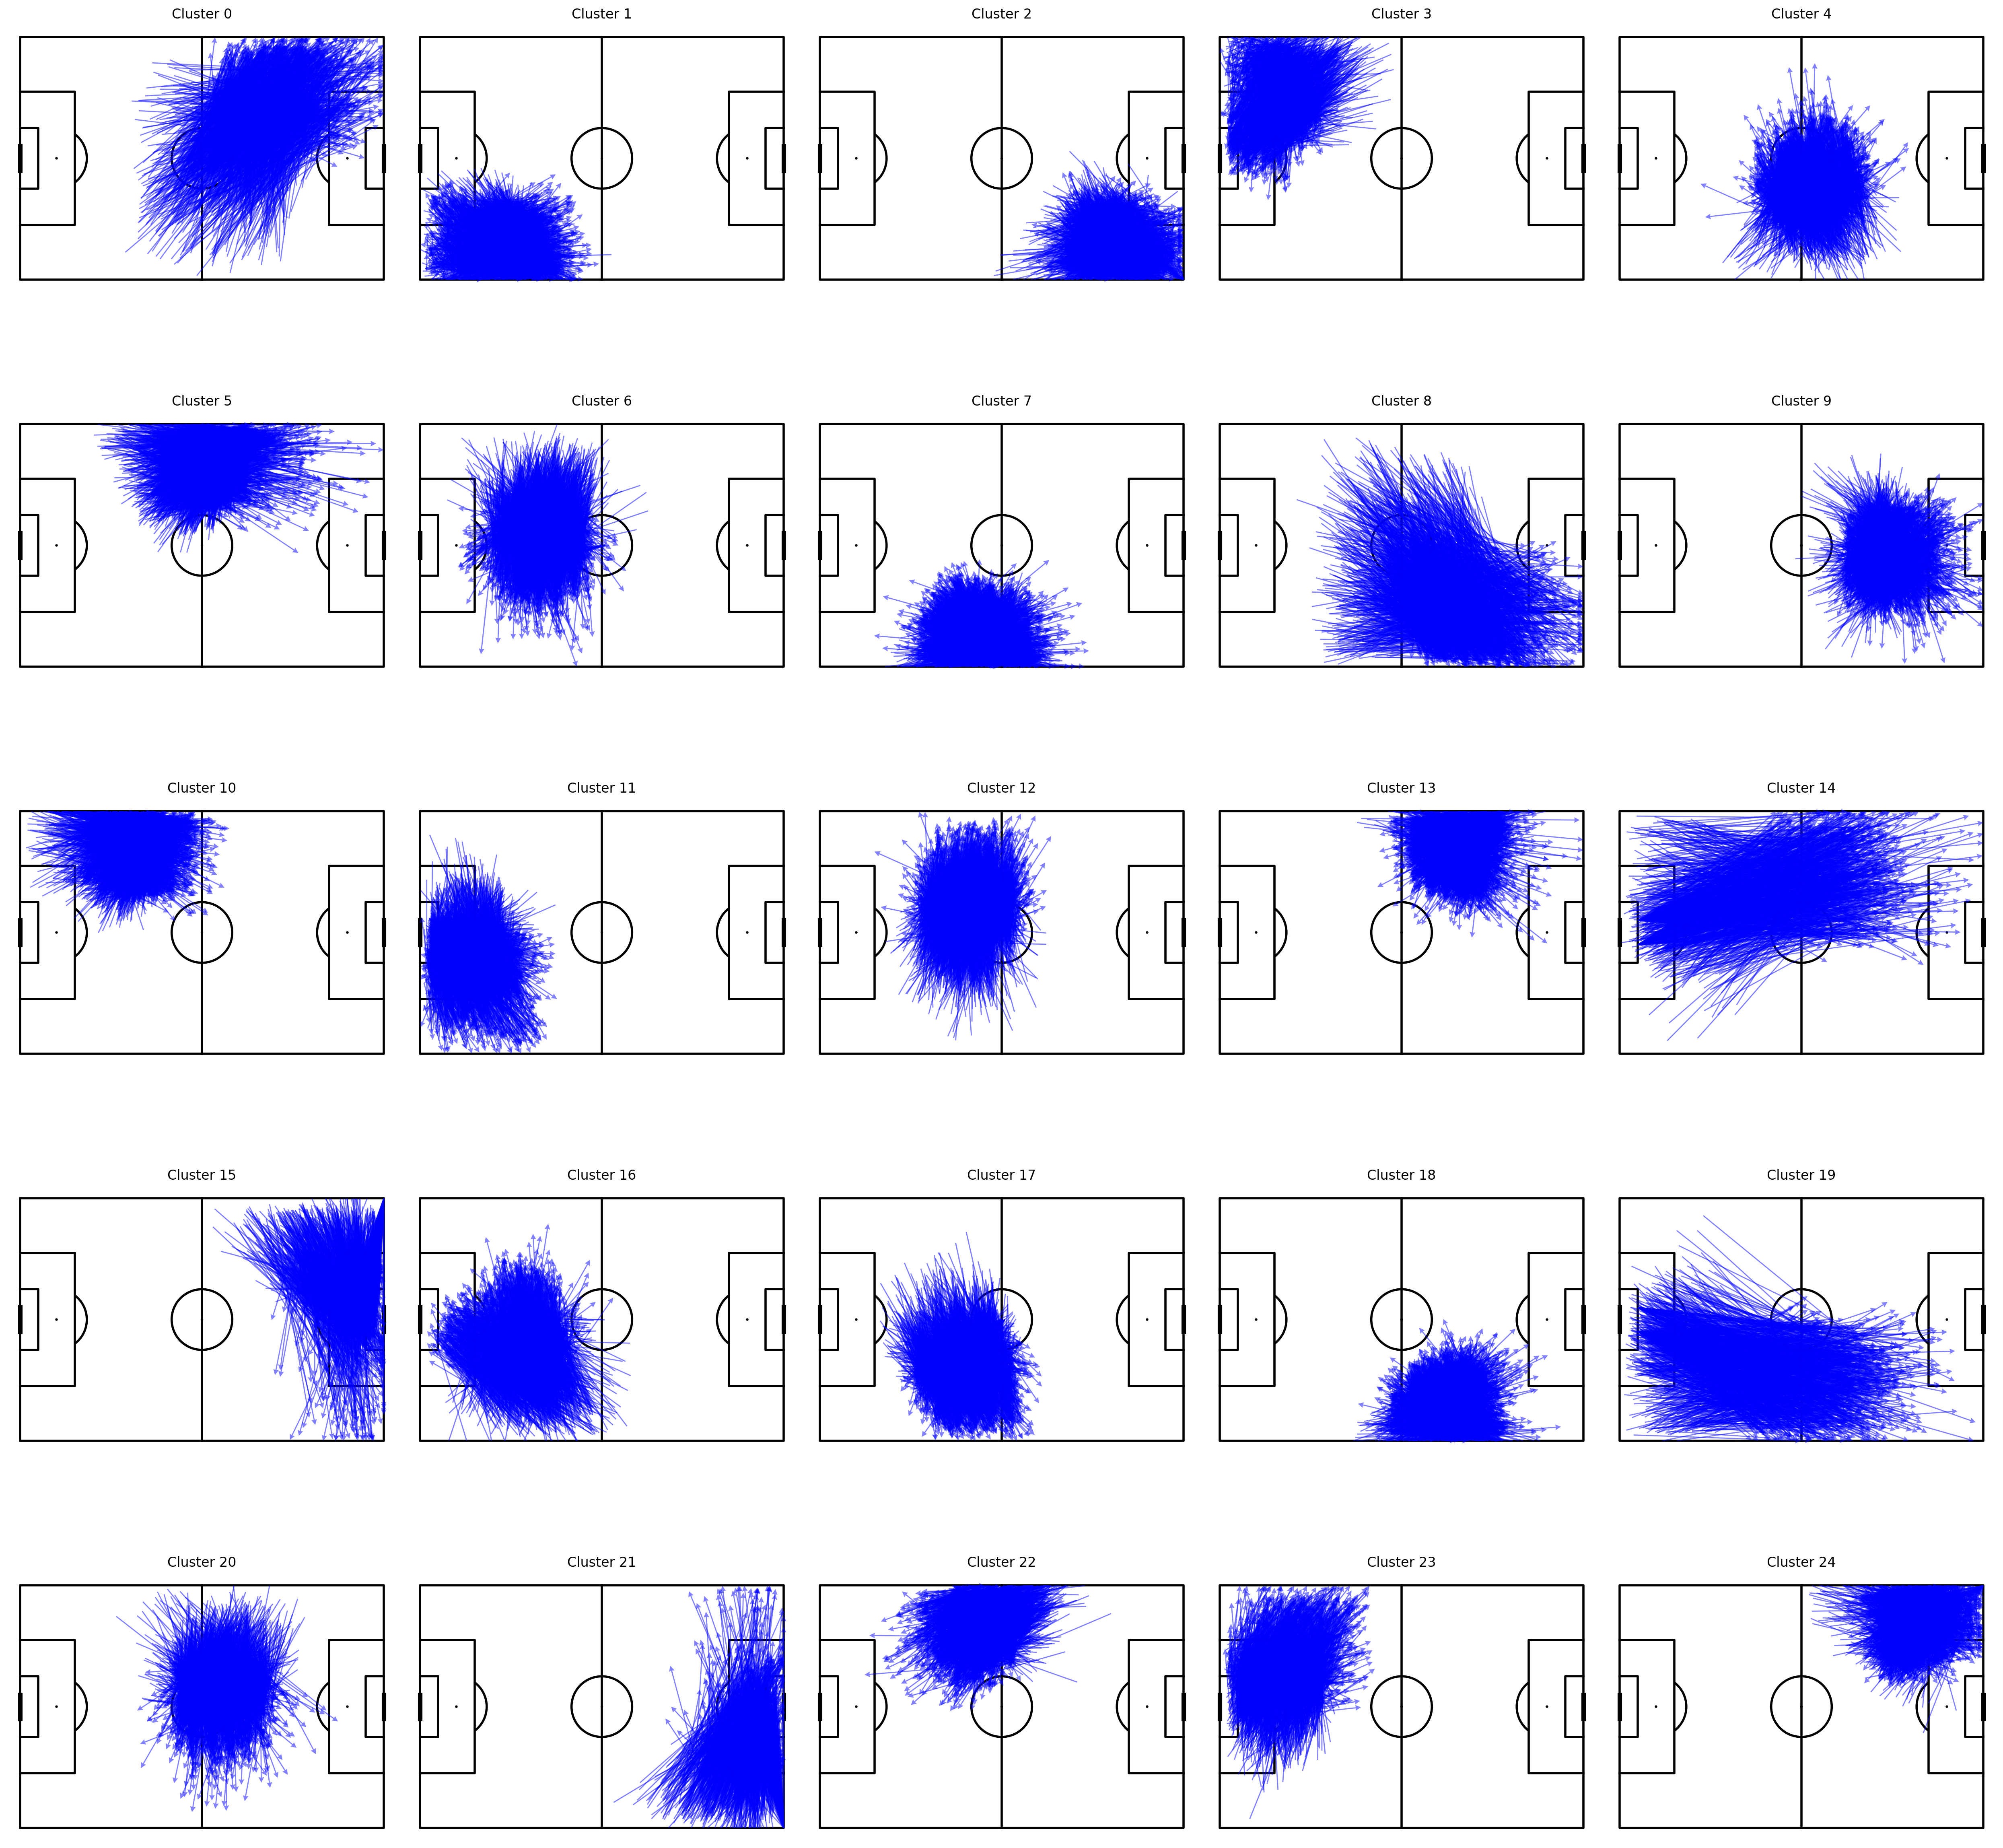

In [10]:
all_passes_df['cluster'] = kmeans.labels_

fig, axs = plt.subplots(5, 5, figsize=(25, 25))
axs = axs.flatten()

pitch = Pitch(pitch_type='statsbomb', line_color='black')

for cluster_id in range(n_clusters):
    cluster_passes = all_passes_df[all_passes_df['cluster'] == cluster_id]
    pitch.draw(ax=axs[cluster_id])
    if not cluster_passes.empty:
        pitch.arrows(
            cluster_passes['start_x'], cluster_passes['start_y'],
            cluster_passes['end_x'], cluster_passes['end_y'],
            headwidth=5, headlength=5, width=1, ax=axs[cluster_id], alpha=0.5, color='blue'
        )
    axs[cluster_id].set_title(f'Cluster {cluster_id}')

plt.tight_layout()
plt.show()

Now, I will create a plot that includes all clusters onto one field, using the centre of the cluster to determine average position

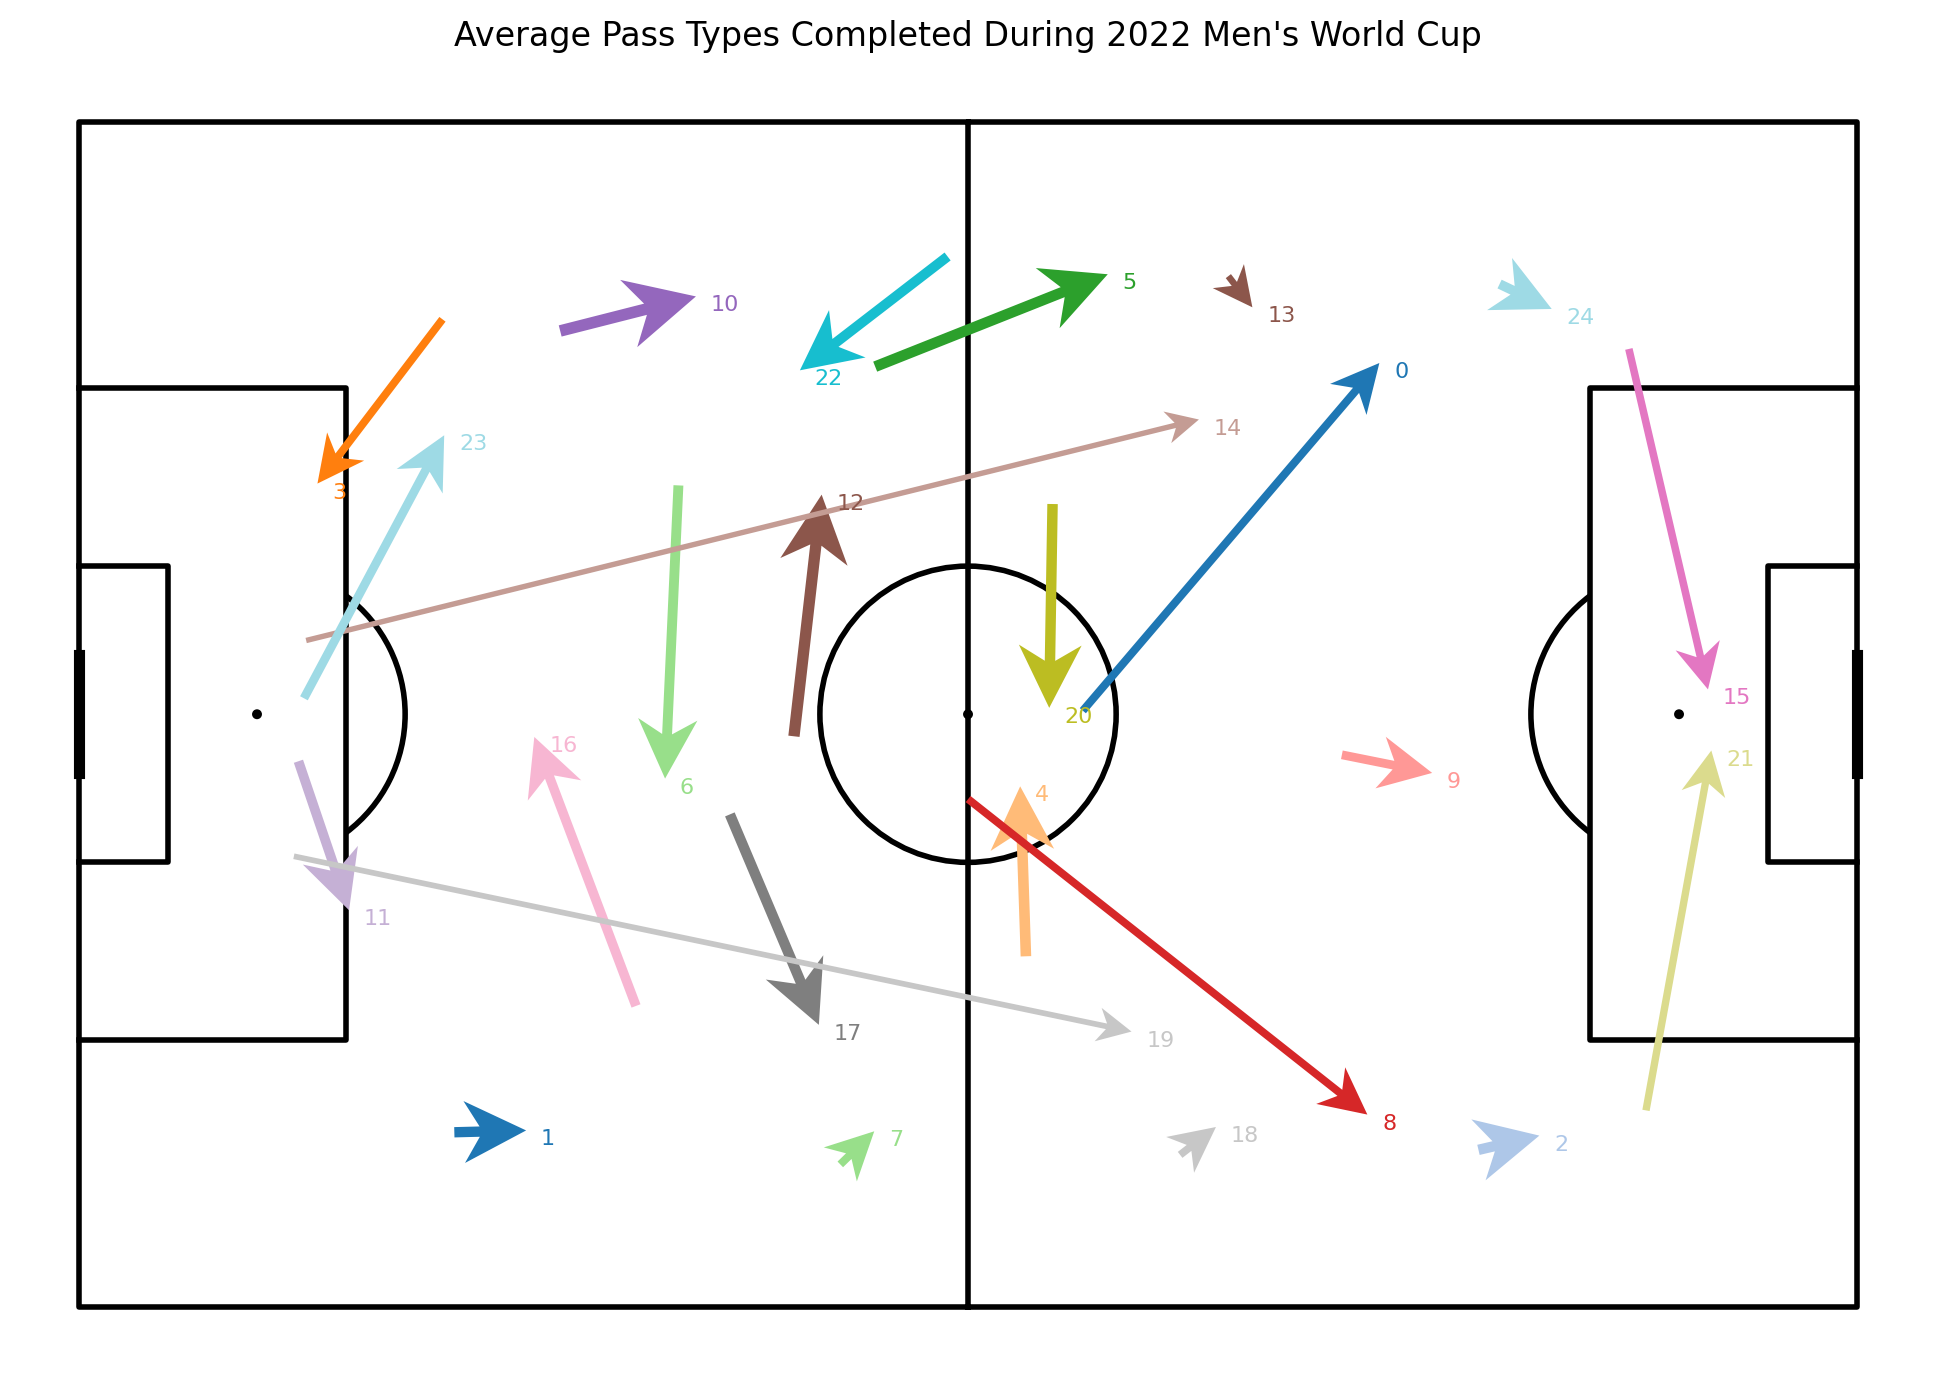

In [18]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Find the centres of the clusters
centers = kmeans.cluster_centers_
cluster_sizes = all_passes_df['cluster'].value_counts().sort_index()
max_size = cluster_sizes.max()

# Setup single pitch
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

# Colormap for distinct colors, have to resample becuase tab 20 only had 20 colours
cmap = plt.colormaps['tab20'].resampled(n_clusters)

# Loop over clusters and plot one average arrow each
# scale width by relative cluster size (1-5 range)
for cluster_id in range(n_clusters):
    start_x, start_y, end_x, end_y = centers[cluster_id]
    size = cluster_sizes.get(cluster_id, 0)
    width = 1 + 4 * (size / max_size)

    pitch.arrows(
        start_x, start_y, end_x, end_y,
        headwidth=6, headlength=6, width=width,
        color=cmap(cluster_id), ax=ax, label=f'Cluster {cluster_id}'
    )

    # Add a cluster identity near the end of the arrow for reference
    ax.text(end_x + 1, end_y + 1, str(cluster_id), color=cmap(cluster_id / (n_clusters - 1)), fontsize=8)


plt.title("Average Pass Types Completed During 2022 Men's World Cup")
plt.show()

# Part 3: Calculate frequency of each pass cluster for Canada during 2022

Start by filtering data for just Canada's matches

In [12]:
canada_matches = matches[(matches['home_team'] == 'Canada') | (matches['away_team'] == 'Canada')]
print(f"Canada's matches: {len(canada_matches)}")

canada_passes = []
for match_id in canada_matches['match_id']:
    events = sb.events(match_id=match_id)
    passes = events[(events['type'] == 'Pass') & (events['team'] == 'Canada')].copy()
    if not passes.empty:
        passes[['start_x', 'start_y']] = pd.DataFrame(passes['location'].tolist(), index=passes.index)
        passes[['end_x', 'end_y']] = pd.DataFrame(passes['pass_end_location'].tolist(), index=passes.index)
        canada_passes.append(passes[['start_x', 'start_y', 'end_x', 'end_y']])

canada_passes_df = pd.concat(canada_passes, ignore_index=True).dropna()

Canada's matches: 3


Create a cluster for Canada's passes

In [13]:
canada_features = canada_passes_df[['start_x', 'start_y', 'end_x', 'end_y']]
canada_passes_df['cluster'] = kmeans.predict(canada_features)

Calculate the frequencies of the clusters

In [14]:
cluster_counts = canada_passes_df['cluster'].value_counts().sort_index()
cluster_percentages = (cluster_counts / len(canada_passes_df)) * 100

print("Canada's pass cluster frequencies (counts):")
print(cluster_counts)
print("\nCanada's pass cluster frequencies (percentages):")
print(cluster_percentages)

Canada's pass cluster frequencies (counts):
cluster
0      58
1      73
2      85
3      46
4      60
5      81
6      64
7      95
8      44
9      67
10     82
11     51
12     82
13    123
14     21
15     42
16     50
17     55
18     86
19     21
20     60
21     50
22     72
23     46
24     57
Name: count, dtype: int64

Canada's pass cluster frequencies (percentages):
cluster
0     3.691916
1     4.646722
2     5.410567
3     2.928071
4     3.819223
5     5.155952
6     4.073838
7     6.047104
8     2.800764
9     4.264799
10    5.219605
11    3.246340
12    5.219605
13    7.829408
14    1.336728
15    2.673456
16    3.182686
17    3.500955
18    5.474220
19    1.336728
20    3.819223
21    3.182686
22    4.583068
23    2.928071
24    3.628262
Name: count, dtype: float64


Created a graph to show Clusters + Frequency

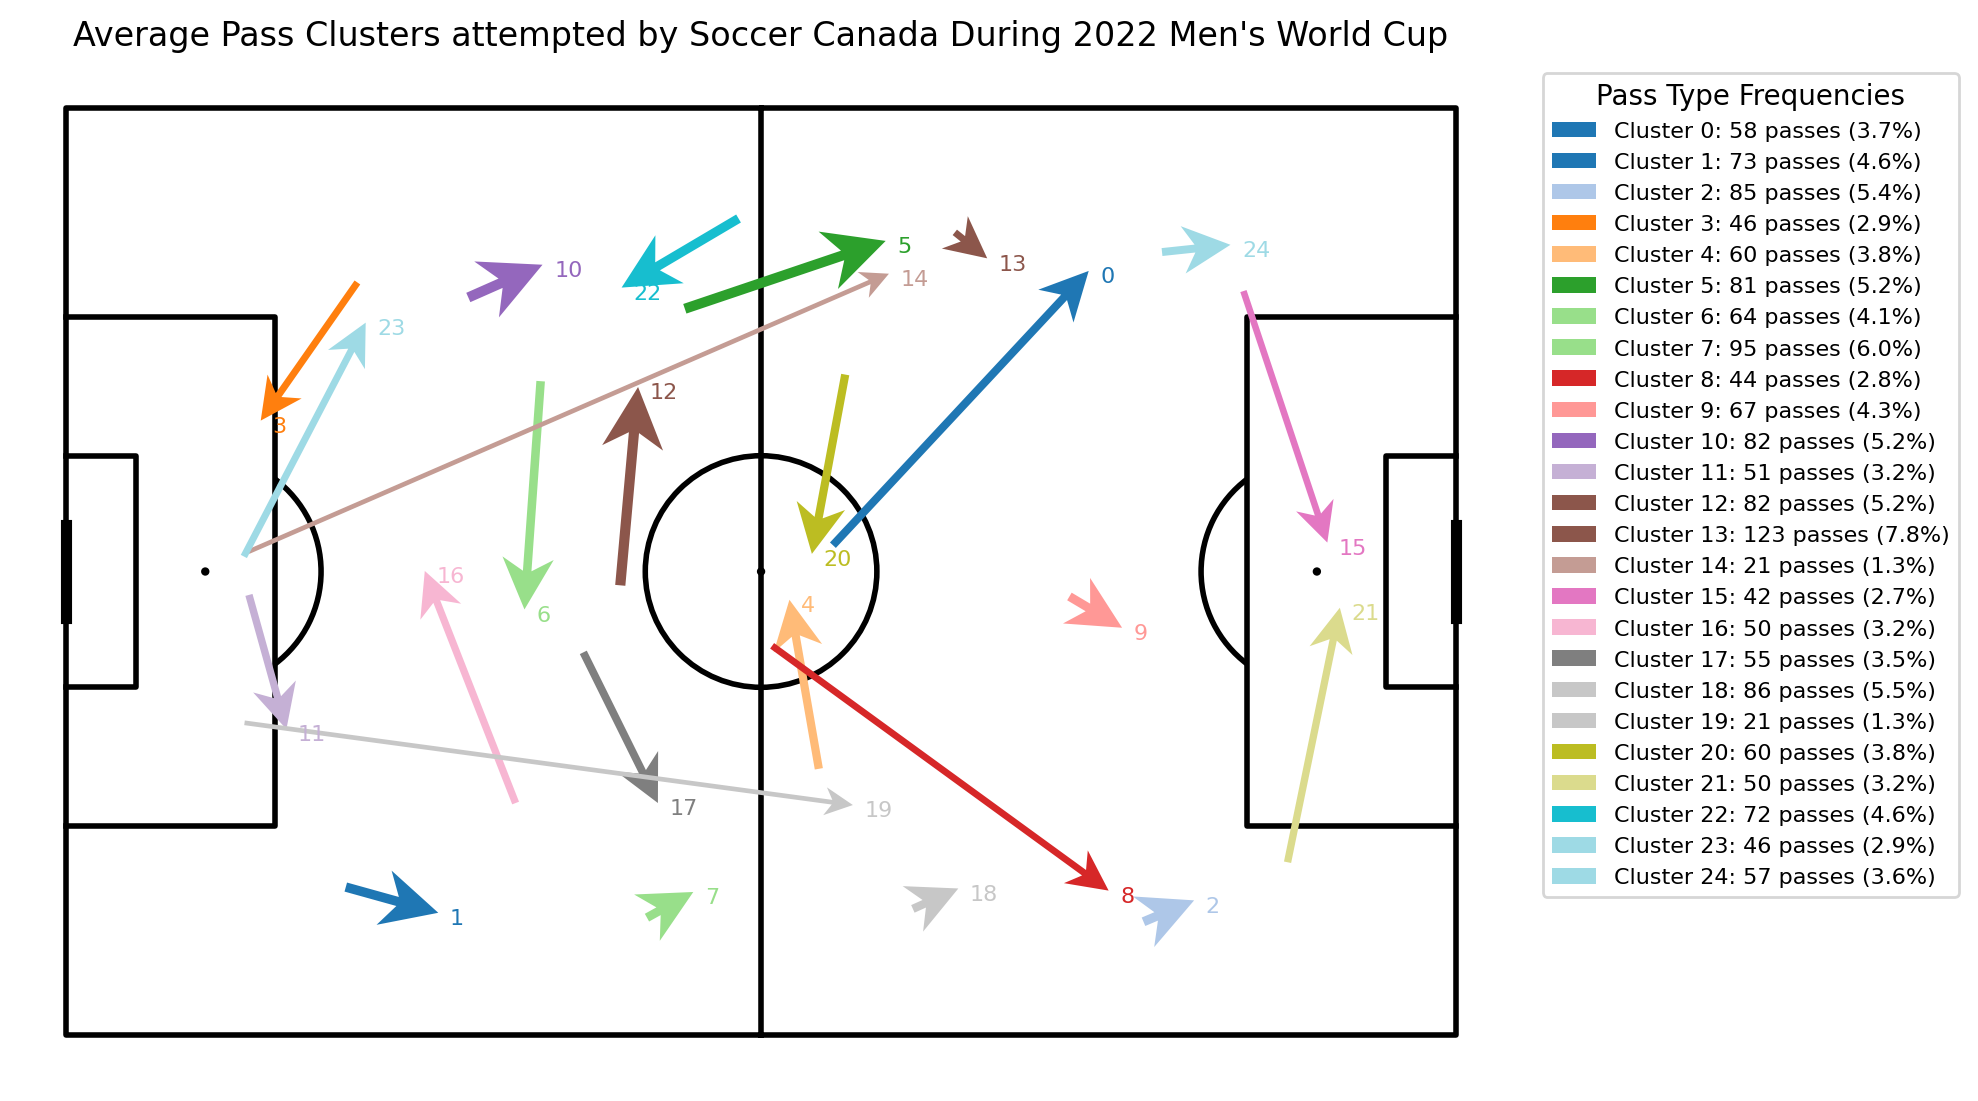

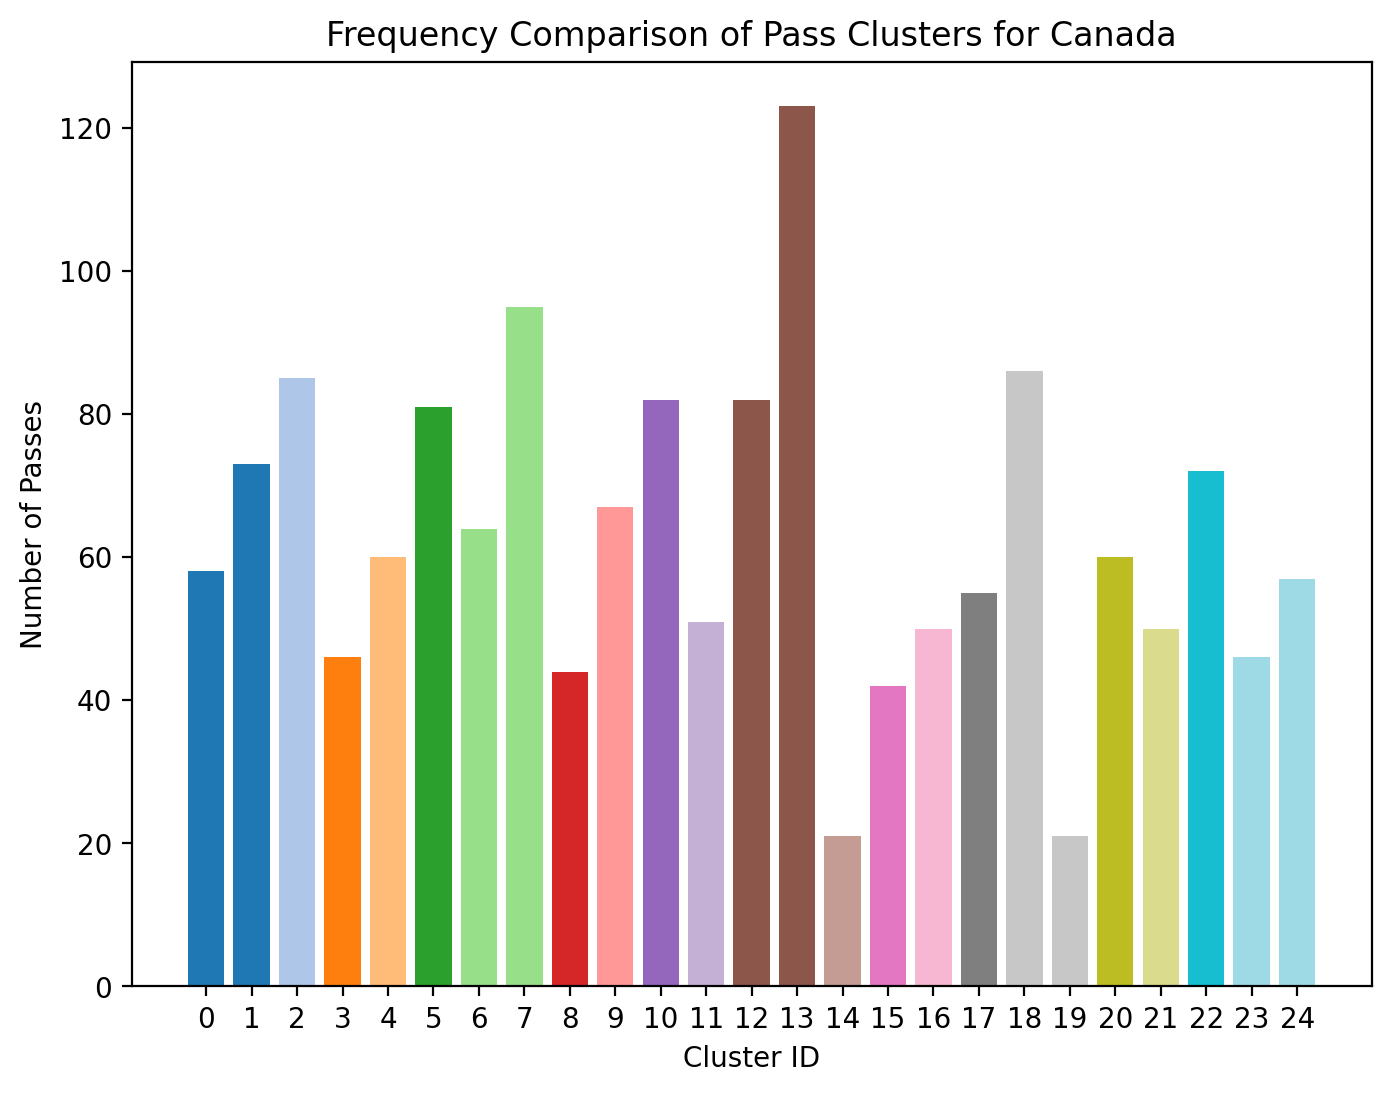

In [21]:
#Plot Pass Cluster Graph for Team Canada 3 games
# Find the centres of the clusters for Canada's passes
canada_centers = canada_passes_df.groupby('cluster')[['start_x', 'start_y', 'end_x', 'end_y']].mean().values
canada_cluster_sizes = canada_passes_df['cluster'].value_counts().sort_index()
max_size = canada_cluster_sizes.max()

# Setup single pitch
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

# Colormap for distinct colors
cmap = plt.colormaps['tab20'].resampled(n_clusters)

# Loop over clusters and plot one average arrow each
for cluster_id in range(n_clusters):
    if cluster_id in canada_cluster_sizes.index:
        start_x, start_y, end_x, end_y = canada_centers[cluster_id]
        size = canada_cluster_sizes.get(cluster_id, 0)
        width = 1 + 4 * (size / max_size)
        pitch.arrows(
            start_x, start_y, end_x, end_y,
            headwidth=6, headlength=6, width=width,
            color=cmap(cluster_id / (n_clusters - 1)),
            ax=ax
        )

        ax.text(end_x + 1, end_y + 1, str(cluster_id), color=cmap(cluster_id / (n_clusters - 1)), fontsize=8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cmap(cluster_id / (n_clusters - 1)),
          label=f"Cluster {cluster_id}: {canada_cluster_sizes.get(cluster_id, 0)} passes ({cluster_percentages.get(cluster_id, 0):.1f}%)")
    for cluster_id in range(n_clusters)
    if cluster_id in canada_cluster_sizes.index
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1),
          title="Pass Type Frequencies", fontsize=8)

plt.title("Average Pass Clusters attempted by Soccer Canada During 2022 Men's World Cup")
plt.show()

#Bar chart to compare frequency of each cluster
fig2, ax2 = plt.subplots(figsize=(8, 6))
clusters = range(n_clusters)
frequencies = [canada_cluster_sizes.get(i, 0) for i in clusters]
colors = [cmap(i / (n_clusters - 1)) for i in clusters]
ax2.bar(clusters, frequencies, color=colors)
ax2.set_xlabel('Cluster ID')
ax2.set_ylabel('Number of Passes')
ax2.set_title('Frequency Comparison of Pass Clusters for Canada')
ax2.set_xticks(clusters)

plt.show()

# Discussion

Looking at the previous model, we can see that the most frequent pass cluster was Cluster 13 (123 passes) which makes up 7.8% of the total passes completed in the three games.

The clusters look to represent types of passes that differ in length (i.e. short, medium, long).

The overall trend of the numbers describes that Canada's game prioritizes more of a possession based playstyle as short passes have the higheset maximal frequency. This is seen by the largest frequencies coming from passes 2, 7, 13, and 18 which are relatively short arrows in the plot.

However, after looking into [extra findings], it was found that medium length passes occured most frequently during the matches (42% medium, 38% short, 20% long). So although the short passes had the highest frequency of individiual pass clusters, the sum of all the clusters show medium taking the crown.

Regarding playstyle, we would still see a relatively controlled approach prioritizing possesion to move down the field.

# Extra

Wanted to see the overall frequency of short,medium, and long passes

In [16]:
# Calculate pass lengths (in meters, assuming StatsBomb units)
def calculate_pass_length_frequencies(df):
    df['length'] = np.sqrt(
        (df['end_x'] - df['start_x'])**2 +
        (df['end_y'] - df['start_y'])**2
    )

    # Define categories (thresholds in meters; adjust if needed)
    def categorize_length(length):
        if length < 15:
            return 'Short'
        elif 15 <= length < 30:
            return 'Medium'
        else:
            return 'Long'

    df['pass_category'] = df['length'].apply(categorize_length)

    # Calculate counts and percentages
    counts = df['pass_category'].value_counts()
    percentages = (counts / len(df)) * 100

    # Combine into a summary DataFrame
    summary = pd.DataFrame({'Count': counts, 'Percentage': percentages}).sort_index()

    return summary

# Combine with Canada dataset
canada_pass_summary = calculate_pass_length_frequencies(canada_passes_df)
print("\nCanada's Pass Length Frequencies:")
print(canada_pass_summary)


Canada's Pass Length Frequencies:
               Count  Percentage
pass_category                   
Long             316   20.114577
Medium           653   41.565882
Short            602   38.319542


**Extra Findings**

Breaking down the three types of passes (short: less than 15m, medium: 15-30m, long: more than 30m), we can confirm that Canada's soccer team prioritized short passes over long passes. However, looking at the count and frequency, medium passes are the most utilized in the Canadian gameplan. This makes sense looking at the plot as although the individual short passes might be most frequent, there does appear to be more medium length pass clusters.